In [1]:
#!pip install -r requirements.txt

In [2]:
import os
from shutil import move
from torchvision.transforms import RandomErasing, ColorJitter
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from kagglehub import kagglehub
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm import tqdm


In [3]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available.")


CUDA is available!
Device name: NVIDIA GeForce RTX 4060 Laptop GPU


In [4]:
def create_dataloaders(train_dataset, test_dataset, batch_size, val_split=0.2, num_workers=4, use_sampler=True):
    """
    Create DataLoaders for training, validation, and testing datasets.

    Args:
        train_dataset: Dataset object for training.
        test_dataset: Dataset object for testing.
        batch_size: Batch size for DataLoaders.
        val_split: Fraction of the training dataset used for validation.
        num_workers: Number of subprocesses for data loading.
        use_sampler: Whether to use WeightedRandomSampler for class imbalance.

    Returns:
        train_loader, val_loader, test_loader: DataLoaders for training, validation, and testing.
    """
    # Split train_dataset into training and validation datasets
    train_size = int((1 - val_split) * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    # Extract labels for the training subset
    train_labels = [train_dataset.targets[i] for i in train_subset.indices]

    # Calculate class counts and weights
    class_counts = np.bincount(train_labels)
    smoothing_factor = 1e-2  # Smoothing to avoid overly high weights
    class_weights = 1. / (class_counts + smoothing_factor)
    class_weights = torch.tensor(class_weights, dtype=torch.float32)

    # Log class weights for debugging
    print(f"Class counts: {class_counts}")
    print(f"Class weights: {class_weights}")

    # Create sample weights for WeightedRandomSampler
    sampler = None
    if use_sampler:
        sample_weights = torch.tensor([class_weights[label] for label in train_labels], dtype=torch.float32)
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    # Create DataLoaders
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        sampler=sampler if use_sampler else None,
        shuffle=not use_sampler,  # Shuffle only if sampler is not used
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,  # No shuffle for validation
        num_workers=num_workers,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,  # No shuffle for testing
        num_workers=num_workers,
        pin_memory=True
    )

    # Log dataset sizes for verification
    print(f"Train size: {len(train_subset)}, Validation size: {len(val_subset)}, Test size: {len(test_dataset)}")

    return train_loader, val_loader, test_loader


In [5]:
def compute_dataset_stats(dataset):
    """
    Computes the mean and standard deviation of a grayscale dataset.

    Args:
        dataset (torch.utils.data.Dataset): Dataset for which to compute statistics.

    Returns:
        tuple: Mean and standard deviation for the single channel.
    """
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
    mean = 0.0
    std = 0.0
    total_samples = 0

    for images, _ in loader:
        batch_samples = images.size(0)  # Batch size
        images = images.view(batch_samples, -1)  # Flatten all pixels into one dimension
        mean += images.mean(1).sum(0)
        std += images.std(1).sum(0)
        total_samples += batch_samples

    mean /= total_samples
    std /= total_samples

    return mean.item(), std.item()


In [6]:
def plot_image_batch(images, labels, class_names):
    """
    Plots a batch of images with their corresponding labels.

    Args:
        images (Tensor): A batch of images (shape: [batch_size, channels, height, width]).
        labels (Tensor): Corresponding labels for the images.
        class_names (list): List of class names corresponding to the labels.
    """

    images = images.permute(0, 2, 3, 1).numpy()

    images = images * 0.5 + 0.5

    batch_size = images.shape[0]
    grid_size = int(batch_size ** 0.5)
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    for i, ax in enumerate(axes.flat):
        if i < batch_size:

            ax.imshow(images[i].squeeze(), cmap="gray" if images[i].shape[-1] == 1 else None)

            ax.set_title(class_names[labels[i]])
            ax.axis("off")
        else:

            ax.axis("off")
    plt.tight_layout()
    plt.show()


In [7]:
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=100, log_interval=100, patience=5):
    writer = SummaryWriter(log_dir="../logs")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    best_val_loss = float('inf')
    patience_counter = 0
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

            if (batch_idx + 1) % log_interval == 0:
                writer.add_scalar("Batch Training Loss", running_loss / log_interval,
                                  epoch * len(train_loader) + batch_idx)
                running_loss = 0.0

        train_accuracy = correct_train / total_train
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss /= len(val_loader)
        val_accuracy = correct_val / total_val
        scheduler.step(val_loss)

        writer.add_scalar("Epoch Training Accuracy", train_accuracy, epoch)
        writer.add_scalar("Epoch Validation Accuracy", val_accuracy, epoch)
        writer.add_scalar("Epoch Validation Loss", val_loss, epoch)
        writer.add_scalar("Epoch Learning Rate", optimizer.param_groups[0]['lr'], epoch)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    writer.close()

In [8]:
def evaluate_model(model, data_loader):
    # Set the device (CUDA if available, otherwise CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to the device
    model = model.to(device)

    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            # Move data to the same device as model
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy


In [9]:
class CNN(nn.Module):
    def __init__(self, input_size=(48, 48), num_classes=8, dropout_rate=0.3):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)  # Batch Norm
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Compute fully connected input size dynamically
        fc_input_size = 128 * (input_size[0] // 8) * (input_size[1] // 8)

        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(fc_input_size, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self._init_weights()

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)


In [10]:
# Generalized permanent dataset path
home_dir = os.path.expanduser("~")  # Gets the user's home directory
permanent_path = os.path.join(home_dir, "datasets")

# Download dataset if it doesn't exist
if not os.path.exists(permanent_path):
    print("Downloading dataset...")
    temp_path = kagglehub.dataset_download("subhaditya/fer2013plus")  # Temporary download path
    print("Moving dataset to permanent location...")
    move(temp_path, permanent_path)
    print("Dataset moved to:", permanent_path)
else:
    print("Dataset already exists at:", permanent_path)

# Identify train and test directories dynamically
train_dir = os.path.join(permanent_path, "fer2013plus", "fer2013", "train")
test_dir = os.path.join(permanent_path, "fer2013plus", "fer2013", "test")

Dataset already exists at: /home/omarhammad/datasets


In [11]:
# Paths for augmented datasets
augmented_train_dir = os.path.join(permanent_path, "fer2013plus/fer2013/train_augmented")
augmented_test_dir = os.path.join(permanent_path, "fer2013plus/fer2013/test_augmented")

# Compute stats for grayscale normalization
train_stats = compute_dataset_stats(datasets.ImageFolder(train_dir, transform=transforms.ToTensor()))
mean, std = train_stats
print(f"Computed Mean: {mean}, Std: {std}")

# Define augmentations for training and deterministic processing for testing
train_augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(3),  # Further reduced rotation
    transforms.RandomCrop(48, padding=2),  # Subtle cropping
    transforms.ColorJitter(brightness=0.05, contrast=0.05),  # Minimal brightness/contrast changes
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.CenterCrop(48),  # Consistent size
    transforms.ToTensor(),
])

# Check if the augmented datasets exist
if not os.path.exists(augmented_train_dir) or not os.path.exists(augmented_test_dir):
    print("Augmented datasets not found. Creating augmented datasets...")

    # Use GPU for processing if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Adjust augmentation count
    augmentation_count = 3  # Generate exactly 2 augmented images per original

    # Process and save the augmented train dataset
    print("Processing train dataset with 3 augmentations per image...")
    for label in os.listdir(train_dir):
        label_dir = os.path.join(train_dir, label)
        save_dir = os.path.join(augmented_train_dir, label)
        os.makedirs(save_dir, exist_ok=True)

        for img_name in tqdm(os.listdir(label_dir), desc=f"Processing {label}"):
            img_path = os.path.join(label_dir, img_name)
            img = Image.open(img_path).convert("L")  # Convert to grayscale (1 channel)

            # Generate 3 augmented images per original
            for i in range(augmentation_count):
                augmented_img = train_augment_transform(img)  # Apply transforms
                augmented_img_pil = transforms.ToPILImage()(augmented_img)  # Convert back to PIL Image
                augmented_img_pil.save(os.path.join(save_dir, f"{os.path.splitext(img_name)[0]}_aug_{i}.png"))

    # Process and save the test dataset
    print("Processing test dataset...")
    for label in os.listdir(test_dir):
        label_dir = os.path.join(test_dir, label)
        save_dir = os.path.join(augmented_test_dir, label)
        os.makedirs(save_dir, exist_ok=True)
        for img_name in tqdm(os.listdir(label_dir), desc=f"Processing {label}"):
            img_path = os.path.join(label_dir, img_name)
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            processed_img = test_transform(img)
            processed_img_pil = transforms.ToPILImage()(processed_img)  # Convert back to PIL Image
            processed_img_pil.save(os.path.join(save_dir, img_name))
else:
    print("Augmented datasets already exist. Skipping processing.")

# Reload processed datasets with normalization applied during loading
train_dataset = datasets.ImageFolder(augmented_train_dir, transform=transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),

]))

test_dataset = datasets.ImageFolder(augmented_test_dir, transform=transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,)),

]))


Computed Mean: 0.5076549053192139, Std: 0.21201835572719574
Augmented datasets already exist. Skipping processing.


In [12]:
# Dataset sizes
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 85158
Test dataset size: 7099


In [13]:
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    batch_size=32,
    val_split=0.2,
    use_sampler=True  # Enable WeightedRandomSampler
)

# Check a sample batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels)

# Get class-to-label mapping
class_names = train_dataset.classes
print("Class Names:", class_names)

# Example: label 0 corresponds to the first class
print("Label 0 is:", class_names[0])



Class counts: [ 5921   384   463  1570 18118 24771  8318  8581]
Class weights: tensor([1.6889e-04, 2.6041e-03, 2.1598e-03, 6.3694e-04, 5.5194e-05, 4.0370e-05,
        1.2022e-04, 1.1654e-04])
Train size: 68126, Validation size: 17032, Test size: 7099
Image batch shape: torch.Size([32, 1, 48, 48])
Labels batch shape: torch.Size([32])
Labels: tensor([1, 7, 5, 4, 3, 2, 0, 7, 6, 5, 0, 7, 1, 1, 2, 1, 0, 4, 7, 4, 2, 2, 5, 1,
        1, 2, 3, 6, 1, 4, 7, 7])
Class Names: ['anger', 'contempt', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Label 0 is: anger


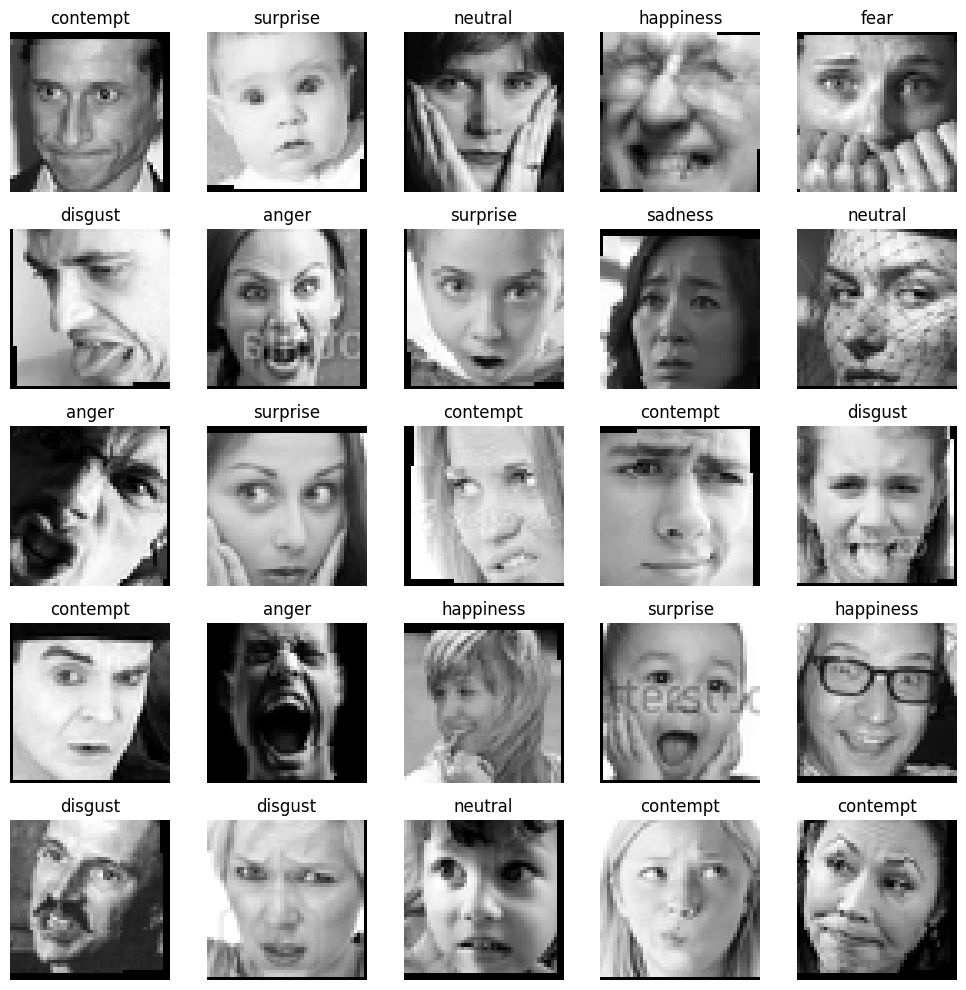

In [14]:
plot_image_batch(images, labels, class_names)


In [15]:
cnn_model = CNN(dropout_rate=0.04)
criterion = nn.CrossEntropyLoss()  # Loss function for classification
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)

In [16]:
train_model(cnn_model, train_loader, val_loader, optimizer, criterion, num_epochs=100, patience=10)
# tensorboard --logdir=../logs

Epoch [1/100], Train Acc: 0.4599, Val Acc: 0.5326, Val Loss: 1.2908
Epoch [2/100], Train Acc: 0.6727, Val Acc: 0.5865, Val Loss: 1.0922
Epoch [3/100], Train Acc: 0.7382, Val Acc: 0.6406, Val Loss: 0.9654
Epoch [4/100], Train Acc: 0.7778, Val Acc: 0.5981, Val Loss: 1.0910
Epoch [5/100], Train Acc: 0.7960, Val Acc: 0.6721, Val Loss: 0.9188
Epoch [6/100], Train Acc: 0.8126, Val Acc: 0.6924, Val Loss: 0.8768
Epoch [7/100], Train Acc: 0.8254, Val Acc: 0.6903, Val Loss: 0.8804
Epoch [8/100], Train Acc: 0.8361, Val Acc: 0.6986, Val Loss: 0.8912
Epoch [9/100], Train Acc: 0.8414, Val Acc: 0.6864, Val Loss: 0.8955
Epoch [10/100], Train Acc: 0.8529, Val Acc: 0.7121, Val Loss: 0.8669
Epoch [11/100], Train Acc: 0.8609, Val Acc: 0.6730, Val Loss: 0.9385
Epoch [12/100], Train Acc: 0.8641, Val Acc: 0.7064, Val Loss: 0.8749
Epoch [13/100], Train Acc: 0.8709, Val Acc: 0.6948, Val Loss: 0.8925
Epoch [14/100], Train Acc: 0.8754, Val Acc: 0.7027, Val Loss: 0.8761
Epoch [15/100], Train Acc: 0.9033, Val Acc:

In [17]:
train_accuracy = evaluate_model(cnn_model, train_loader)
print(f"Train Accuracy: {train_accuracy:.4f}")

Train Accuracy: 0.9855


In [18]:
test_accuracy = evaluate_model(cnn_model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7308


In [19]:
torch.save(cnn_model.state_dict(), 'initial_cnn_model.pth')